## Camera Calibration Explorer
Notebook for loading chessboard pattern images to compute camera intrinsic and extrinsic matrices, perform lens distortion removal, and validate the calibration by projecting 3D space points into 2D image coordinates using OpenCV. 

*Optional: Includes stereo camera calibration to determine the 3D spatial location of points present in both images.*

**Team:** Pedro Tricossi & Juliana Zambon


### 1. Environment Setup and Library Imports

In [9]:
# Core libraries for numerical operations and image processing
import numpy as np
import cv2

# File path manipulation
import glob

# Visualization
import matplotlib.pyplot as plt

# Print library versions for environment tracking
print(f"OpenCV Version: {cv2.__version__}")
print(f"NumPy Version: {np.__version__}")

# Helper function to display images in the Jupyter environment
def show_image(img, title="Image", cmap=None):
    plt.figure(figsize=(10, 6))
    if cmap is None:
        # Convert BGR (OpenCV default) to RGB for Matplotlib
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

OpenCV Version: 5.0.0
NumPy Version: 2.5.2


### 2. Preparation of 3D Object Points and 2D Image Points
The VRI chessboard has known dimensions. To calibrate, we need to map 3D points in the real world to their 2D projections in the images.

* **3D Points (Object Points):** We assume the chessboard is fixed on the $Z = 0$ plane. Coordinates are $(0,0,0), (1,0,0), (2,0,0) ...$ multiplied by the real square size (in mm).
* **2D Points (Image Points):** The internal corners detected by OpenCV using `findChessboardCorners`.

In [10]:
# --- CHESSBOARD CONFIGURATION ---
CHECKERBOARD = (7, 7) 
SQUARE_SIZE = 25.0    # Physical size of a square in millimeters 

# Termination criteria for sub-pixel corner refinement
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Prepare 3D object points like (0,0,0), (25,0,0), (50,0,0) ...
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2) * SQUARE_SIZE

# Arrays to store object points and image points from all the images
objpoints = [] # 3D points in real world space
imgpoints = [] # 2D points in image plane

# Load images (Create a folder named 'calibration_images' and place your photos there)
images = glob.glob('calibration_images/*.jpeg')

if not images:
    print("No images found! Please check the folder path.")

for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Find the chessboard corners
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)

    # If found, add object points and image points (after refining them)
    if ret == True:
        objpoints.append(objp)
        
        # Refine corner coordinates to sub-pixel accuracy
        corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        imgpoints.append(corners2)

        # Draw and display the corners (Optional step for debugging)
        # img_draw = cv2.drawChessboardCorners(img.copy(), CHECKERBOARD, corners2, ret)
        # show_image(img_draw, f"Detected Corners - {fname}")

### 3. Camera Calibration and Distortion Removal
Using the paired 3D and 2D points, we use `cv2.calibrateCamera` to compute:
- `mtx`: Intrinsic Camera Matrix (focal length and optical centers).
- `dist`: Distortion Coefficients (radial and tangential).
- `rvecs` and `tvecs`: Extrinsic Matrices (rotation and translation vectors).

Once obtained, we apply `cv2.undistort` to an image to visually verify the removal of lens distortion (e.g., barrel or pincushion effects).

Camera Matrix (Intrinsic):
 [[1.10242802e+03 0.00000000e+00 9.47750499e+02]
 [0.00000000e+00 1.10509839e+03 5.61692643e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion Coefficients:
 [[ 0.04623608 -0.12153125 -0.00138612 -0.00383273  0.08026978]]


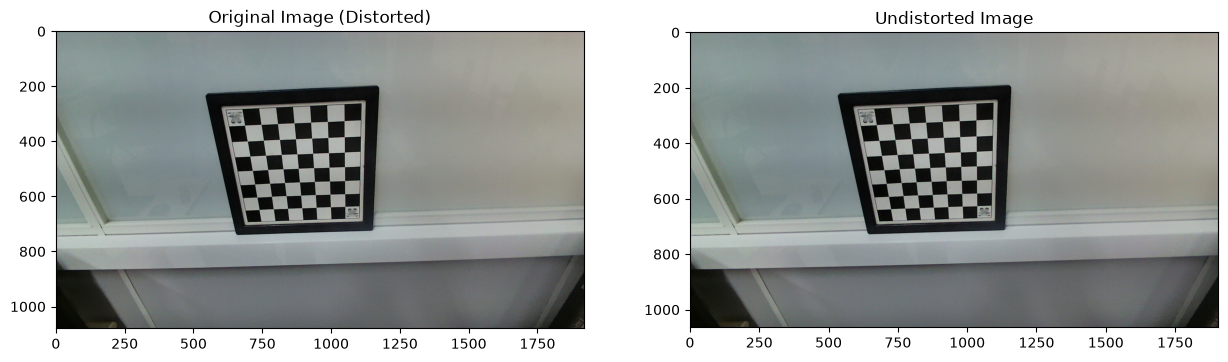

In [11]:
# Perform camera calibration
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

print("Camera Matrix (Intrinsic):\n", mtx)
print("\nDistortion Coefficients:\n", dist)

# --- UNDISTORTION PROCESS ---
# Test the undistortion on the first image
img_test = cv2.imread(images[0])
h, w = img_test.shape[:2]

# Refine the camera matrix based on a free scaling parameter (alpha)
# alpha=1 retains all pixels (including black borders), alpha=0 crops them
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1, (w, h))

# Apply the undistortion
dst = cv2.undistort(img_test, mtx, dist, None, newcameramtx)

# Crop the image based on the ROI (Optional)
x, y, w_roi, h_roi = roi
dst = dst[y:y+h_roi, x:x+w_roi]

# Plot Before and After
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
ax1.imshow(cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB))
ax1.set_title('Original Image (Distorted)')
ax2.imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
ax2.set_title('Undistorted Image')
plt.show()

### 4. Experiment: 3D to 2D Projection & Reprojection Error
To validate our calibration, this experiment takes the known 3D object points (`objpoints`) and mathematically projects them back onto the 2D image plane using our newly calculated intrinsic matrix and extrinsic vectors (`cv2.projectPoints`).

By measuring the Euclidean distance between the *mathematically projected* 2D points and the *actual detected* 2D corners, we find the **Reprojection Error**. A lower error (closer to zero) indicates a highly accurate calibration.

In [12]:
mean_error = 0
errors_per_image = []

for i in range(len(objpoints)):
    imgpoints_projected, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
    
    img_pts_real = imgpoints[i].reshape(-1, 2).astype(np.float32)
    img_pts_proj = imgpoints_projected.reshape(-1, 2).astype(np.float32)
    
    error = cv2.norm(img_pts_real, img_pts_proj, cv2.NORM_L2) / len(img_pts_proj)
    
    errors_per_image.append(error)
    mean_error += error

total_error = mean_error / len(objpoints)

print(f"Total Average Reprojection Error: {total_error:.5f} pixels")

Total Average Reprojection Error: 0.07659 pixels


### 5. Visual Comparison of Undistortion on Multiple Images
To visually validate the calibration, this section selects images from the dataset and displays a side-by-side comparison between the original (distorted) and the corrected (undistorted) versions.

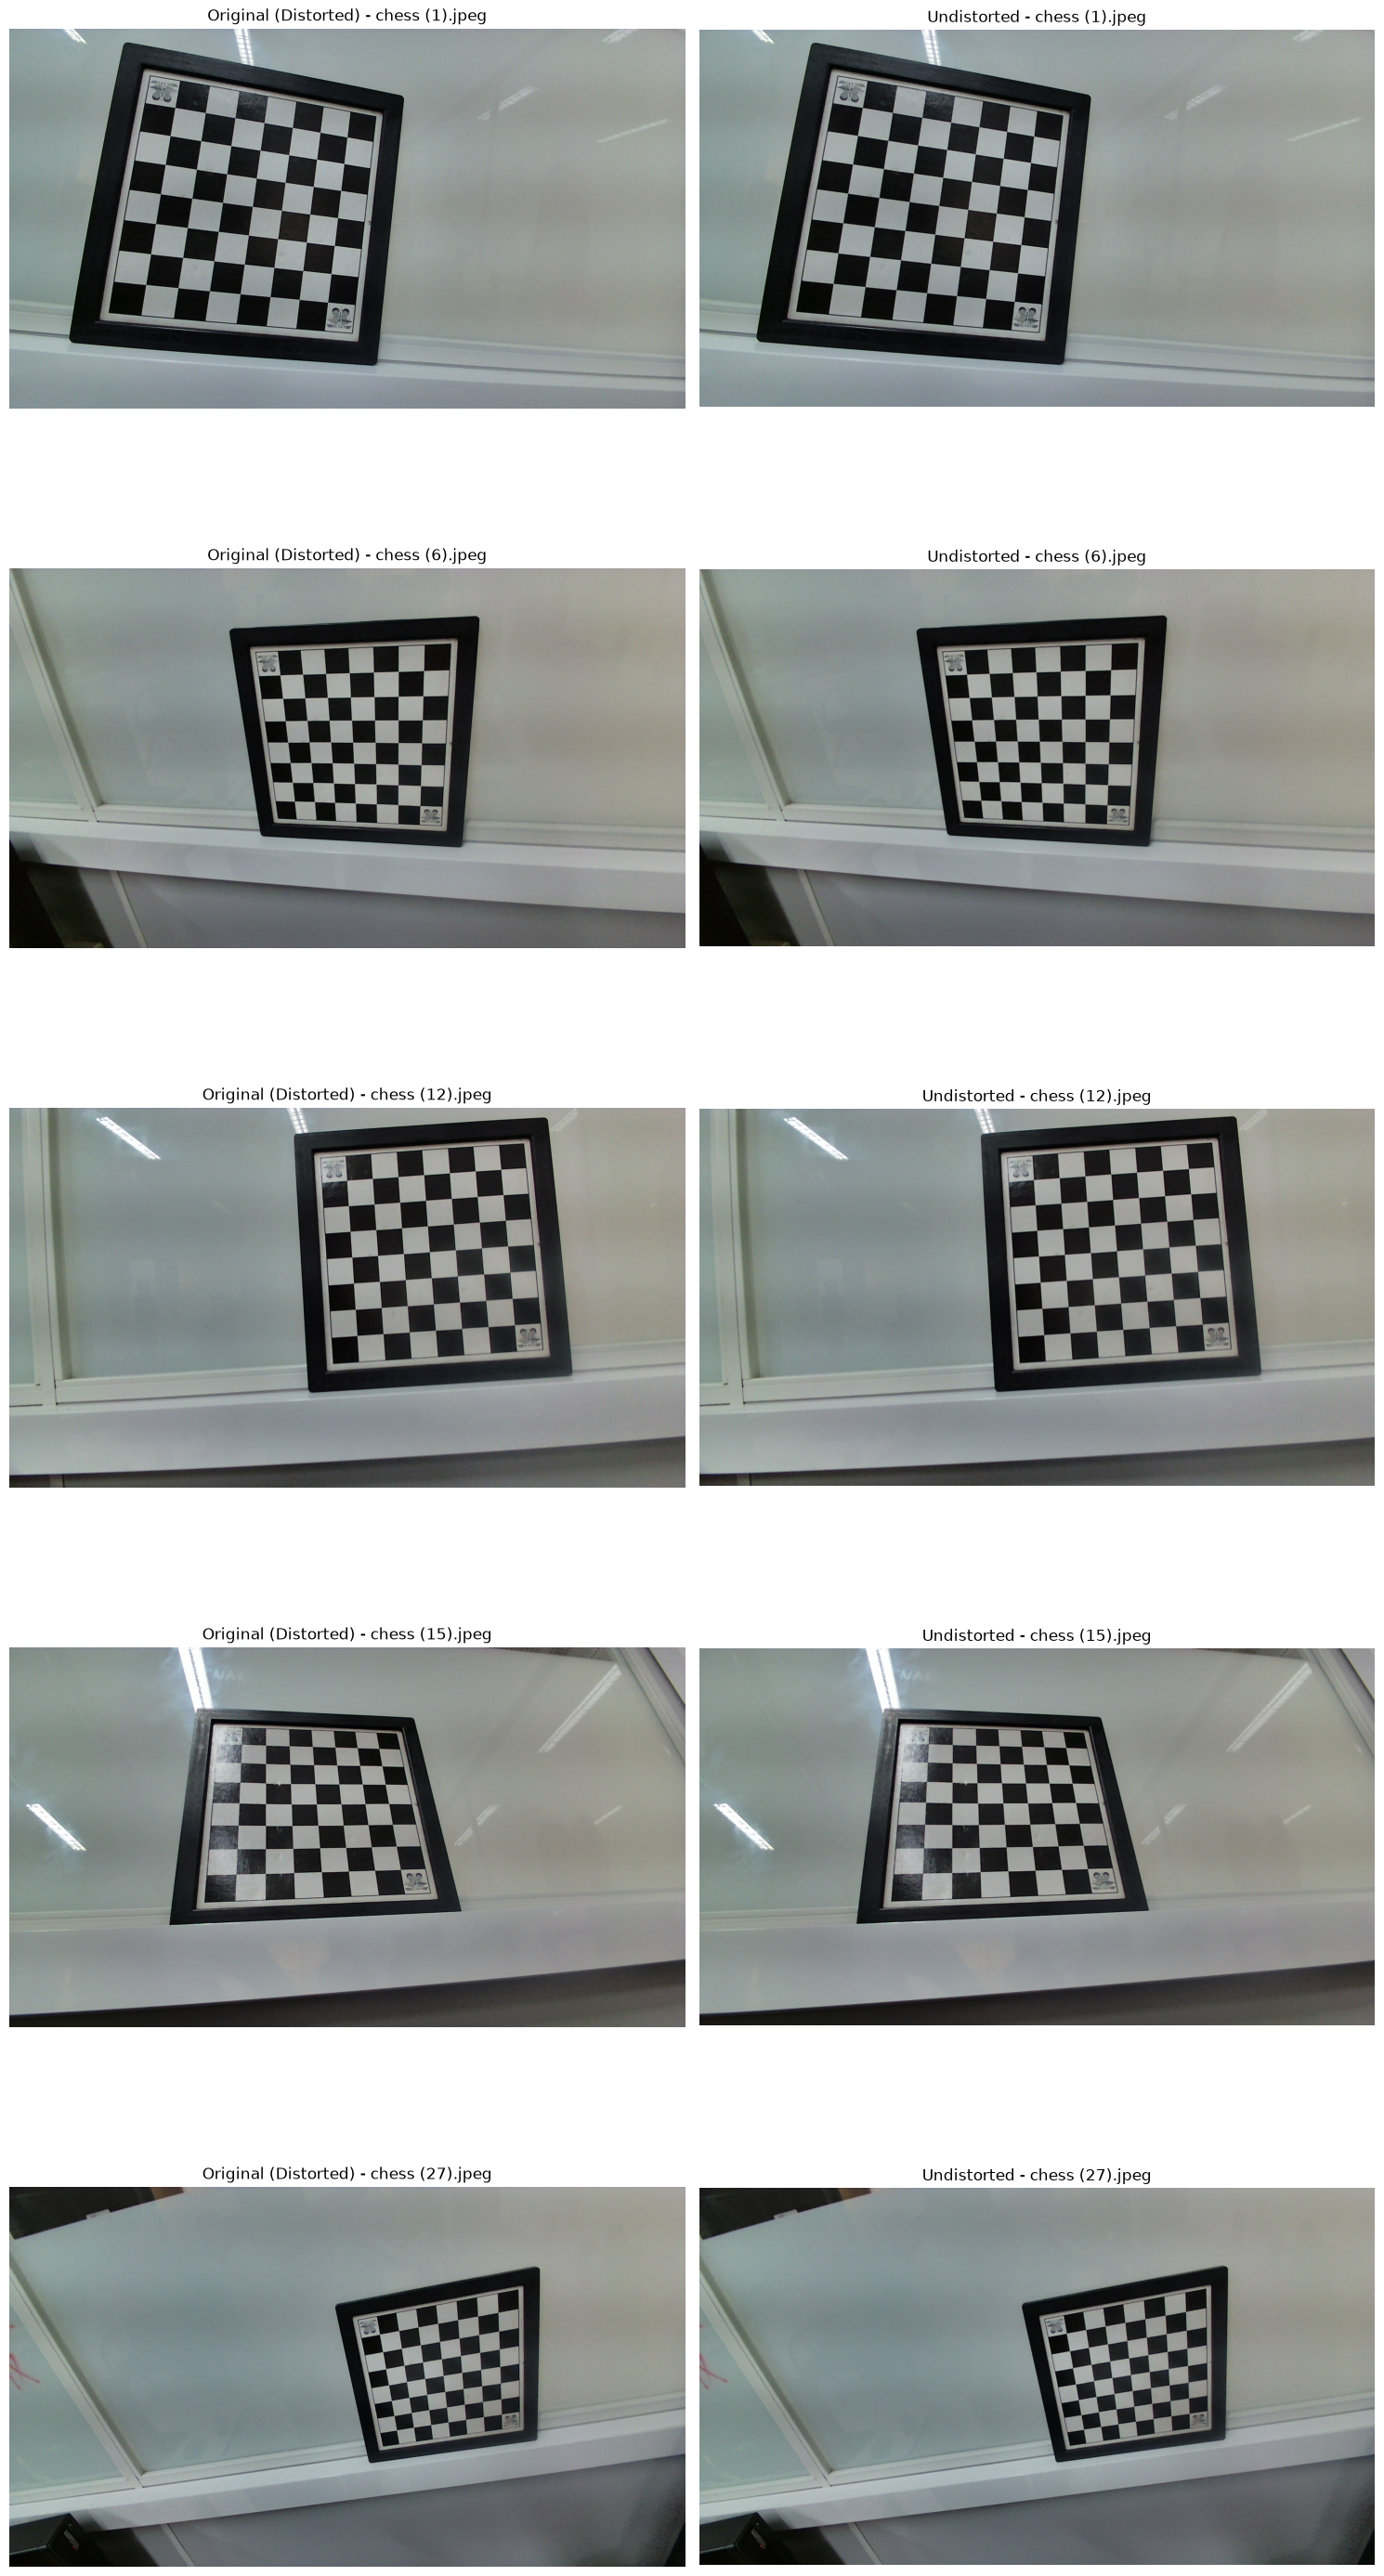

In [13]:
import os

filenames = [
    "chess (1).jpeg",
    "chess (6).jpeg",
    "chess (12).jpeg",
    "chess (15).jpeg",
    "chess (27).jpeg"
] 

sample_images = [f"calibration_images/{name}" for name in filenames]

num_images_to_show = len(sample_images)

# Set up the plot size based on the number of images
plt.figure(figsize=(15, 6 * num_images_to_show))

for i, img_path in enumerate(sample_images):
    img_test = cv2.imread(img_path)
    
        
    h, w = img_test.shape[:2]
    
    # Get the optimal camera matrix
    newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1, (w, h))
    
    # Apply distortion removal (undistort)
    dst = cv2.undistort(img_test, mtx, dist, None, newcameramtx)
    
    # Crop useless borders based on Region of Interest (ROI)
    x, y, w_roi, h_roi = roi
    dst = dst[y:y+h_roi, x:x+w_roi]
    
    file_name = os.path.basename(img_path)
    
    # Plot the Original image (left column)
    plt.subplot(num_images_to_show, 2, 2*i + 1)
    plt.imshow(cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB))
    plt.title(f'Original (Distorted) - {file_name}')
    plt.axis('off')
    
    # Plot the Undistorted image (right column)
    plt.subplot(num_images_to_show, 2, 2*i + 2)
    plt.imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
    plt.title(f'Undistorted - {file_name}')
    plt.axis('off')

plt.tight_layout()
plt.show()